###### w

## Image Classification PreTrained Version
## What is this animal ? feature

### import libraries

In [88]:
from sklearn.model_selection import train_test_split
import os
import shutil
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from keras.layers import Dense, Flatten ,Dropout, Conv2D, MaxPooling2D, BatchNormalization , GlobalAveragePooling2D
from keras.models import Sequential
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import Callback, EarlyStopping,ModelCheckpoint, ReduceLROnPlateau
import evaluate
from transformers import (
    AutoTokenizer,
    TFAutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    AdamWeightDecay
)
from keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
EFFNET_WEIGHTS_PATH = r"C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\Image classification what is this feature Pretrained\efficientnetb0_notop.h5"
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

### GPU configuration

In [2]:
print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ memory growth enabled")

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
print("✅ mixed precision:", mixed_precision.global_policy())

TF: 2.10.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ memory growth enabled
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060 Laptop GPU, compute capability 8.6
✅ mixed precision: <Policy "mixed_float16">


### Data Preparing (just define the Directory to each , We did the unzip and split in Scratch version)

In [3]:
img_size = (224, 224)
batch_size = 32

base_dir  = r"C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\animals10_split"
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")

print(train_dir)
print(test_dir)

C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\animals10_split\train
C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\animals10_split\test


### to savd the model 

In [4]:
save_dir = r"C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\Image classification what is this feature Pretrained\saved_models"
os.makedirs(save_dir, exist_ok=True)
print("Saving models to:", save_dir)

Saving models to: C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\Image classification what is this feature Pretrained\saved_models


### Model Loading (EfficientNet) , Data Augmentation and building the models 

#### 1st experiment

##### preprocessing (data augmentation + loading the images + EfficientNet processor)

In [5]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen_pt1 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen_pt1 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds_pt1 = train_datagen_pt1.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds_pt1 = test_datagen_pt1.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

class_names = list(train_ds_pt1.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)


Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Num classes: 10


##### Model structure and Training the model experiments

###### Load EfficientNetB0 and load the wights on it 

In [6]:
from tensorflow.keras.applications import EfficientNetB0

base_model_pt1 = EfficientNetB0(
    include_top=False,
    weights=None,
    input_shape=(224,224, 3),
)
base_model_pt1.load_weights(r"C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\Image classification what is this feature Pretrained\efficientnetb0_notop.h5")
base_model_pt1.summary()


Model: "efficientnetb0"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 224, 224, 3)  0           ['input_1[0][0]']                
                                                                                                  
 normalization (Normalization)  (None, 224, 224, 3)  7           ['rescaling[0][0]']              
                                                                                                  
 stem_conv_pad (ZeroPadding2D)  (None, 225, 225, 3)  0           ['normalization[0][0

In [7]:
base_model_pt1.trainable = False  # freeze

model_pt1 = Sequential([
    base_model_pt1,
    GlobalAveragePooling2D(),  
    Dropout(0.2),
    Dense(10, activation="softmax")
])
model_pt1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 10)                12810     
                                                                 
Total params: 4,062,381
Trainable params: 12,810
Non-trainable params: 4,049,571
_________________________________________________________________


In [8]:
model_pt1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history_pt1 = model_pt1.fit(
    train_ds_pt1,
    epochs=10,
    validation_data=test_ds_pt1,
)


Epoch 1/10
786/786 [==============================] - 316s 390ms/step - loss: 0.2804 - accuracy: 0.9283 - val_loss: 0.0966 - val_accuracy: 0.9725
Epoch 2/10
786/786 [==============================] - 220s 280ms/step - loss: 0.1361 - accuracy: 0.9596 - val_loss: 0.0762 - val_accuracy: 0.9789
Epoch 3/10
786/786 [==============================] - 207s 263ms/step - loss: 0.1200 - accuracy: 0.9632 - val_loss: 0.0683 - val_accuracy: 0.9798
Epoch 4/10
786/786 [==============================] - 209s 266ms/step - loss: 0.1172 - accuracy: 0.9641 - val_loss: 0.0609 - val_accuracy: 0.9831
Epoch 5/10
786/786 [==============================] - 207s 263ms/step - loss: 0.1055 - accuracy: 0.9682 - val_loss: 0.0566 - val_accuracy: 0.9836
Epoch 6/10
786/786 [==============================] - 205s 261ms/step - loss: 0.0993 - accuracy: 0.9695 - val_loss: 0.0567 - val_accuracy: 0.9844
Epoch 7/10
786/786 [==============================] - 211s 269ms/step - loss: 0.1028 - accuracy: 0.9682 - val_loss: 0.0527 -

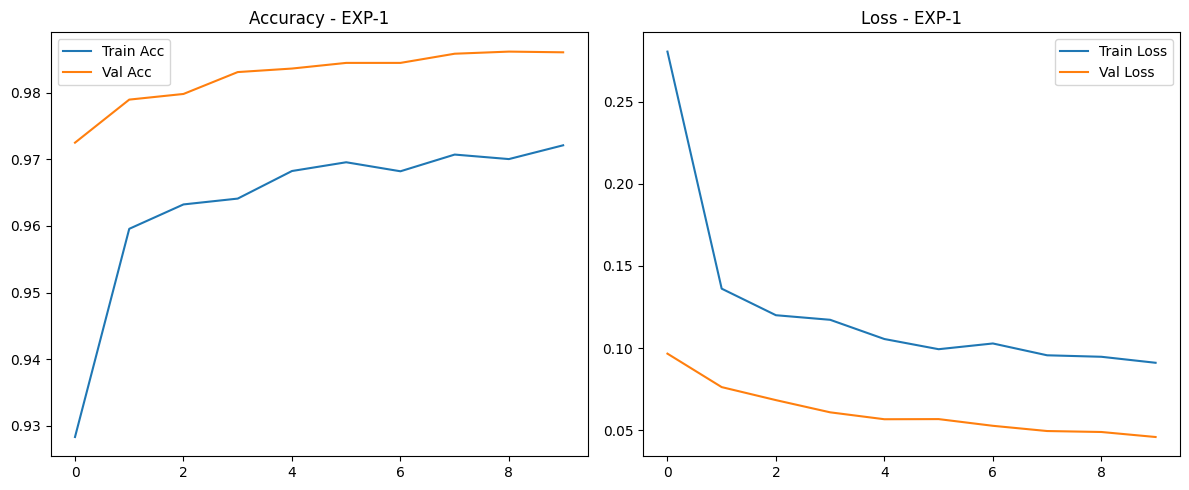

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_pt1.history['accuracy'], label='Train Acc')
plt.plot(history_pt1.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-1')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_pt1.history['loss'], label='Train Loss')
plt.plot(history_pt1.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-1')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
model_pt1.save(os.path.join(save_dir, "animals10_exp1_pt1.h5"))

#### 2nd experiment (increse batch size + add more layers )

##### preprocessing (data augmentation + loading the images + EfficientNet processor)

In [10]:
from tensorflow.keras.applications.efficientnet import preprocess_input

img_size = (224, 224)
batch_size = 64

train_datagen_pt2 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen_pt2 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds_pt2 = train_datagen_pt2.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds_pt2 = test_datagen_pt2.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

class_names = list(train_ds_pt2.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Num classes: 10


##### Model structure and Training the model experiments

###### Load EfficientNetB0 and load the wights on it 

In [11]:
EFFNET_WEIGHTS_PATH = r"C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\Image classification what is this feature Pretrained\efficientnetb0_notop.h5"

base_model_pt2 = EfficientNetB0(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3),
)
base_model_pt2.load_weights(EFFNET_WEIGHTS_PATH)

base_model_pt2.trainable = False  # freeze 


In [12]:
model_pt2 = Sequential([
    base_model_pt2,
    GlobalAveragePooling2D(),
    Dropout(0.30),
    Dense(256, activation="relu"),
    Dropout(0.30),
    Dense(10, activation="softmax")
])
model_pt2.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_1 (Dropout)         (None, 1280)              0         
                                                                 
 dense_1 (Dense)             (None, 256)               327936    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 10)                2570      
                                                      

In [13]:
early_pt2 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_pt2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

ckpt_pt2 = ModelCheckpoint(
    "animals_effnet_pt2_best.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [14]:
from keras.optimizers import Adam
model_pt2.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
history_pt2 = model_pt2.fit(
    train_ds_pt2,
    epochs=15,
    validation_data=test_ds_pt2,
    callbacks=[early_pt2, reduce_lr_pt2, ckpt_pt2],
)

Epoch 1/15
393/393 [==============================] - ETA: 0s - loss: 0.2365 - accuracy: 0.9301
Epoch 1: val_accuracy improved from -inf to 0.97544, saving model to animals_effnet_pt2_best.h5
393/393 [==============================] - 208s 517ms/step - loss: 0.2365 - accuracy: 0.9301 - val_loss: 0.0795 - val_accuracy: 0.9754 - lr: 0.0010
Epoch 2/15
393/393 [==============================] - ETA: 0s - loss: 0.1393 - accuracy: 0.9564
Epoch 2: val_accuracy improved from 0.97544 to 0.98317, saving model to animals_effnet_pt2_best.h5
393/393 [==============================] - 199s 507ms/step - loss: 0.1393 - accuracy: 0.9564 - val_loss: 0.0604 - val_accuracy: 0.9832 - lr: 0.0010
Epoch 3/15
393/393 [==============================] - ETA: 0s - loss: 0.1273 - accuracy: 0.9588
Epoch 3: val_accuracy improved from 0.98317 to 0.98444, saving model to animals_effnet_pt2_best.h5
393/393 [==============================] - 199s 507ms/step - loss: 0.1273 - accuracy: 0.9588 - val_loss: 0.0554 - val_accu

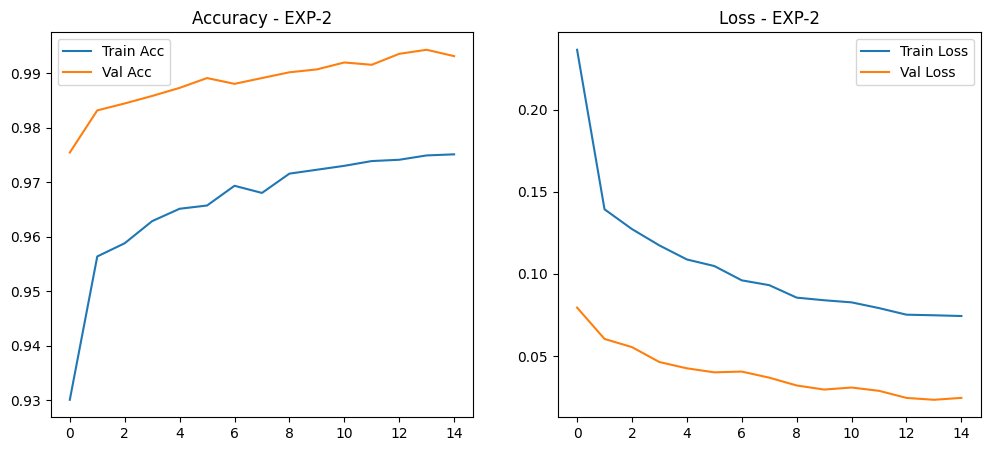

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_pt2.history['accuracy'], label='Train Acc')
plt.plot(history_pt2.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-2')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_pt2.history['loss'], label='Train Loss')
plt.plot(history_pt2.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-2')
plt.legend()


plt.show()

In [30]:
model_pt2.save(os.path.join(save_dir, "animals10_exp2_pt2.h5"))

#### 3rd experiment (decrese layers + unfreeze some layers to fine-tune + edit the augmentation + Add steps_per_epoch and validation_steps + use smaller learning rate )

In [17]:
img_size = (224, 224)
batch_size = 64

train_datagen_pt3 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen_pt3 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds_pt3 = train_datagen_pt3.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds_pt3 = test_datagen_pt3.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

class_names = list(train_ds_pt3.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)


Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Num classes: 10


In [18]:
base_model_pt3 = EfficientNetB0(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3),
)
base_model_pt3.load_weights(EFFNET_WEIGHTS_PATH)

base_model_pt3.trainable = True


In [19]:
# freeze all except last 30 layers
for layer in base_model_pt3.layers[:-30]:
    layer.trainable = False


In [20]:
model_pt3 = Sequential([
    base_model_pt3,
    GlobalAveragePooling2D(),
    Dropout(0.2),
    Dense(10, activation="softmax")
])
model_pt3.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_2   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_3 (Dropout)         (None, 1280)              0         
                                                                 
 dense_3 (Dense)             (None, 10)                12810     
                                                                 
Total params: 4,062,381
Trainable params: 1,508,970
Non-trainable params: 2,553,411
_________________________________________________________________


In [21]:
early_pt3 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_pt3 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

ckpt_pt3 = ModelCheckpoint(
    "animals_effnet_pt3_best.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [22]:
model_pt3.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
history_pt3 = model_pt3.fit(
    train_ds_pt3,
    epochs=15,
    validation_data=test_ds_pt3,
    steps_per_epoch=len(train_ds_pt3),
    validation_steps=len(test_ds_pt3),
    callbacks=[early_pt3, reduce_lr_pt3, ckpt_pt3],
)

Epoch 1/15
393/393 [==============================] - ETA: 0s - loss: 1.5519 - accuracy: 0.6034
Epoch 1: val_accuracy improved from -inf to 0.89097, saving model to animals_effnet_pt3_best.h5
393/393 [==============================] - 203s 500ms/step - loss: 1.5519 - accuracy: 0.6034 - val_loss: 0.7785 - val_accuracy: 0.8910 - lr: 1.0000e-05
Epoch 2/15
393/393 [==============================] - ETA: 0s - loss: 0.6721 - accuracy: 0.8781
Epoch 2: val_accuracy improved from 0.89097 to 0.94464, saving model to animals_effnet_pt3_best.h5
393/393 [==============================] - 194s 494ms/step - loss: 0.6721 - accuracy: 0.8781 - val_loss: 0.3468 - val_accuracy: 0.9446 - lr: 1.0000e-05
Epoch 3/15
393/393 [==============================] - ETA: 0s - loss: 0.3991 - accuracy: 0.9165
Epoch 3: val_accuracy improved from 0.94464 to 0.95702, saving model to animals_effnet_pt3_best.h5
393/393 [==============================] - 198s 502ms/step - loss: 0.3991 - accuracy: 0.9165 - val_loss: 0.2223 - 

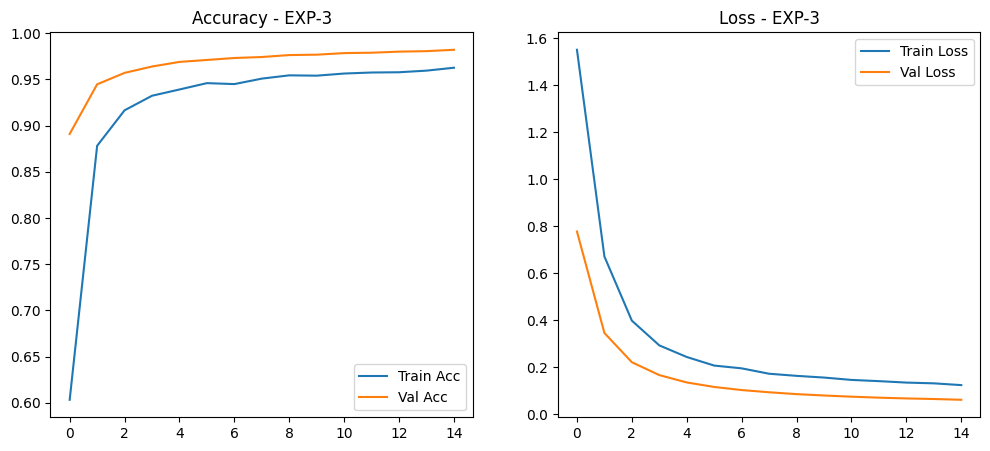

In [26]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_pt3.history['accuracy'], label='Train Acc')
plt.plot(history_pt3.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-3')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_pt3.history['loss'], label='Train Loss')
plt.plot(history_pt3.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-3')
plt.legend()

plt.show()

In [31]:
model_pt3.save(os.path.join(save_dir, "animals10_exp3_pt3.h5"))

#### 4th experiment (Unfreeze more layers + Unfreeze more layers + Add a slightly stronger head + Keep BatchNorm frozen + increase number of epochs)

In [5]:
from tensorflow.keras.applications.efficientnet import preprocess_input

img_size = (224, 224)
batch_size = 64

train_datagen_pt4 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen_pt4 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds_pt4 = train_datagen_pt4.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds_pt4 = test_datagen_pt4.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

class_names = list(train_ds_pt4.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)


Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Num classes: 10


In [9]:
base_model_pt4 = EfficientNetB0(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3),
)
base_model_pt4.load_weights(EFFNET_WEIGHTS_PATH)

base_model_pt4.trainable = True


In [10]:
# freeze all except last 60 layers (more fine-tuning than exp-3)
for layer in base_model_pt4.layers[:-60]:
    layer.trainable = False

# keep al batch freezed
for layer in base_model_pt4.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


In [11]:
model_pt4 = Sequential([
    base_model_pt4,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

model_pt4.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                2570      
                                                                 
Total params: 4,380,077
Trainable params: 2,979,786
Non-trainable params: 1,400,291
______________________________________

In [12]:
early_pt4 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_pt4 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

ckpt_pt4 = ModelCheckpoint(
    "animals_effnet_pt4_best.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [15]:
model_pt4.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history_pt4 = model_pt4.fit(
    train_ds_pt4,
    epochs=20,
    validation_data=test_ds_pt4,
    steps_per_epoch=len(train_ds_pt4),
    validation_steps=len(test_ds_pt4),
    callbacks=[early_pt4, reduce_lr_pt4, ckpt_pt4],
)

Epoch 1/20
393/393 [==============================] - ETA: 0s - loss: 1.0562 - accuracy: 0.7133
Epoch 1: val_accuracy improved from -inf to 0.95628, saving model to animals_effnet_pt4_best.h5
393/393 [==============================] - 291s 714ms/step - loss: 1.0562 - accuracy: 0.7133 - val_loss: 0.2130 - val_accuracy: 0.9563 - lr: 1.0000e-05
Epoch 2/20
393/393 [==============================] - ETA: 0s - loss: 0.2378 - accuracy: 0.9308
Epoch 2: val_accuracy improved from 0.95628 to 0.96824, saving model to animals_effnet_pt4_best.h5
393/393 [==============================] - 209s 530ms/step - loss: 0.2378 - accuracy: 0.9308 - val_loss: 0.1108 - val_accuracy: 0.9682 - lr: 1.0000e-05
Epoch 3/20
393/393 [==============================] - ETA: 0s - loss: 0.1761 - accuracy: 0.9476
Epoch 3: val_accuracy improved from 0.96824 to 0.97332, saving model to animals_effnet_pt4_best.h5
393/393 [==============================] - 197s 502ms/step - loss: 0.1761 - accuracy: 0.9476 - val_loss: 0.0891 - 

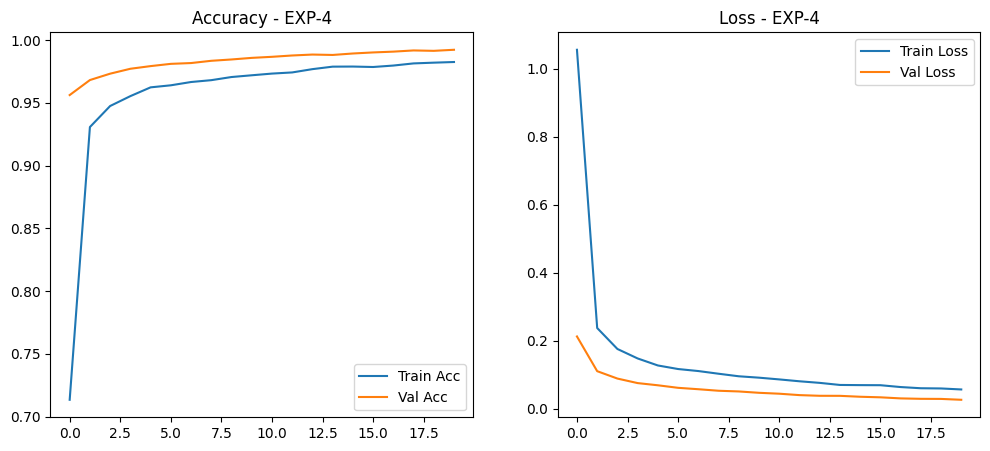

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_pt4.history['accuracy'], label='Train Acc')
plt.plot(history_pt4.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-4')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_pt4.history['loss'], label='Train Loss')
plt.plot(history_pt4.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-4')
plt.legend()

plt.show()

In [18]:
model_pt4.save(os.path.join(save_dir, "animals10_exp4_pt4.h5"))

#### 5th experiment (add regularization (l2) + edit dropout + edit the aggumentation + keep the unfreeze layers 60 , batch freeze and lr small + increase number of epochs)

In [19]:
img_size = (224, 224)
batch_size = 64

train_datagen_pt5 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.12,
    height_shift_range=0.12,
    zoom_range=0.20,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen_pt5 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds_pt5 = train_datagen_pt5.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds_pt5 = test_datagen_pt5.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

class_names = list(train_ds_pt5.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Num classes: 10


In [20]:
base_model_pt5 = EfficientNetB0(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3),
)
base_model_pt5.load_weights(EFFNET_WEIGHTS_PATH)

base_model_pt5.trainable = True#

In [21]:
for layer in base_model_pt5.layers[:-60]:
    layer.trainable = False

# keep el batch 
for layer in base_model_pt5.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [26]:
from keras.regularizers import l2
model_pt5 = Sequential([
    base_model_pt5,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])
model_pt5.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_3   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_4 (Dense)             (None, 256)               327936    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_5 (Dense)             (None, 10)                2570      
                                                                 
Total params: 4,380,077
Trainable params: 2,979,786
Non-trainable params: 1,400,291
____________________________________

In [27]:
early_pt5 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_pt5 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

ckpt_pt5 = ModelCheckpoint(
    "animals_effnet_pt5_best.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [28]:
model_pt5.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
history_pt5 = model_pt5.fit(
    train_ds_pt5,
    epochs=25,
    validation_data=test_ds_pt5,
    steps_per_epoch=len(train_ds_pt5),
    validation_steps=len(test_ds_pt5),
    callbacks=[early_pt5, reduce_lr_pt5, ckpt_pt5],
)

Epoch 1/25
393/393 [==============================] - ETA: 0s - loss: 1.1243 - accuracy: 0.7038
Epoch 1: val_accuracy improved from -inf to 0.95364, saving model to animals_effnet_pt5_best.h5
393/393 [==============================] - 310s 774ms/step - loss: 1.1243 - accuracy: 0.7038 - val_loss: 0.2630 - val_accuracy: 0.9536 - lr: 1.0000e-05
Epoch 2/25
393/393 [==============================] - ETA: 0s - loss: 0.2969 - accuracy: 0.9260
Epoch 2: val_accuracy improved from 0.95364 to 0.96676, saving model to animals_effnet_pt5_best.h5
393/393 [==============================] - 255s 647ms/step - loss: 0.2969 - accuracy: 0.9260 - val_loss: 0.1553 - val_accuracy: 0.9668 - lr: 1.0000e-05
Epoch 3/25
393/393 [==============================] - ETA: 0s - loss: 0.2293 - accuracy: 0.9440
Epoch 3: val_accuracy improved from 0.96676 to 0.97258, saving model to animals_effnet_pt5_best.h5
393/393 [==============================] - 259s 659ms/step - loss: 0.2293 - accuracy: 0.9440 - val_loss: 0.1362 - 

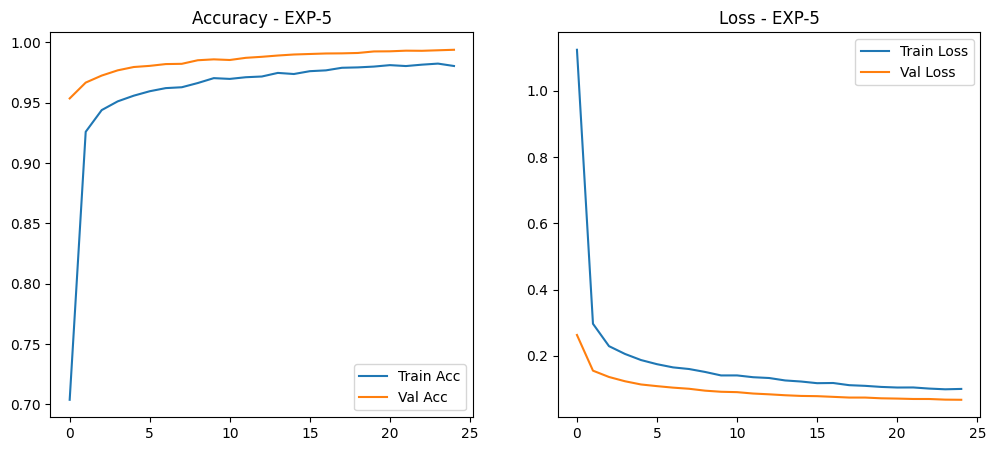

In [30]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_pt5.history['accuracy'], label='Train Acc')
plt.plot(history_pt5.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-5')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_pt5.history['loss'], label='Train Loss')
plt.plot(history_pt5.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-5')
plt.legend()

plt.show()

In [31]:
model_pt5.save(os.path.join(save_dir, "animals10_exp5_pt5.h5"))

####  6th experiment (2-stage fine-tune) : 
#### Stage 1: freeze backbone, train only the head (fast, stable).

#### Stage 2: unfreeze last 40 layers (keep BatchNorm frozen), train with small LR.

##### Stage 1: freeze backbone, train only the head (fast, stable).

In [33]:
img_size = (224, 224)
batch_size = 64

train_datagen_pt6 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.12,
    height_shift_range=0.12,
    zoom_range=0.20,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen_pt6 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds_pt6 = train_datagen_pt6.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds_pt6 = test_datagen_pt6.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

class_names = list(train_ds_pt6.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Num classes: 10


In [34]:
base_model_pt6 = EfficientNetB0(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3),
)
base_model_pt6.load_weights(EFFNET_WEIGHTS_PATH)

# Stage 1: freeze whole backbone
base_model_pt6.trainable = False

In [35]:
model_pt6 = Sequential([
    base_model_pt6,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model_pt6.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_4   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_6 (Dense)             (None, 256)               327936    
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                                 
 dense_7 (Dense)             (None, 10)                2570      
                                                                 
Total params: 4,380,077
Trainable params: 330,506
Non-trainable params: 4,049,571
______________________________________

In [36]:
early_pt6 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_pt6 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

ckpt_pt6 = ModelCheckpoint(
    "animals_effnet_pt6_best.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


In [37]:
model_pt6.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_pt6_stage1 = model_pt6.fit(
    train_ds_pt6,
    epochs=8,
    validation_data=test_ds_pt6,
    steps_per_epoch=len(train_ds_pt6),
    validation_steps=len(test_ds_pt6),
    callbacks=[early_pt6, reduce_lr_pt6, ckpt_pt6],
)


Epoch 1/8
393/393 [==============================] - ETA: 0s - loss: 0.2703 - accuracy: 0.9338
Epoch 1: val_accuracy improved from -inf to 0.97841, saving model to animals_effnet_pt6_best.h5
393/393 [==============================] - 225s 554ms/step - loss: 0.2703 - accuracy: 0.9338 - val_loss: 0.1206 - val_accuracy: 0.9784 - lr: 0.0010
Epoch 2/8
393/393 [==============================] - ETA: 0s - loss: 0.1824 - accuracy: 0.9592
Epoch 2: val_accuracy improved from 0.97841 to 0.98211, saving model to animals_effnet_pt6_best.h5
393/393 [==============================] - 196s 498ms/step - loss: 0.1824 - accuracy: 0.9592 - val_loss: 0.1073 - val_accuracy: 0.9821 - lr: 0.0010
Epoch 3/8
393/393 [==============================] - ETA: 0s - loss: 0.1628 - accuracy: 0.9648
Epoch 3: val_accuracy improved from 0.98211 to 0.98391, saving model to animals_effnet_pt6_best.h5
393/393 [==============================] - 194s 493ms/step - loss: 0.1628 - accuracy: 0.9648 - val_loss: 0.1035 - val_accurac

##### (Stage 2: unfreeze last 40 layers + train small LR)

In [38]:
base_model_pt6.trainable = True

for layer in base_model_pt6.layers[:-40]:
    layer.trainable = False

for layer in base_model_pt6.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_pt6.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_pt6_stage2 = model_pt6.fit(
    train_ds_pt6,
    epochs=20,
    validation_data=test_ds_pt6,
    steps_per_epoch=len(train_ds_pt6),
    validation_steps=len(test_ds_pt6),
    callbacks=[early_pt6, reduce_lr_pt6, ckpt_pt6],
)


Epoch 1/20
393/393 [==============================] - ETA: 0s - loss: 0.1206 - accuracy: 0.9791
Epoch 1: val_accuracy improved from 0.99026 to 0.99206, saving model to animals_effnet_pt6_best.h5
393/393 [==============================] - 204s 507ms/step - loss: 0.1206 - accuracy: 0.9791 - val_loss: 0.0841 - val_accuracy: 0.9921 - lr: 1.0000e-05
Epoch 2/20
393/393 [==============================] - ETA: 0s - loss: 0.1104 - accuracy: 0.9823
Epoch 2: val_accuracy did not improve from 0.99206
393/393 [==============================] - 193s 491ms/step - loss: 0.1104 - accuracy: 0.9823 - val_loss: 0.0829 - val_accuracy: 0.9921 - lr: 1.0000e-05
Epoch 3/20
393/393 [==============================] - ETA: 0s - loss: 0.1062 - accuracy: 0.9827
Epoch 3: val_accuracy improved from 0.99206 to 0.99270, saving model to animals_effnet_pt6_best.h5
393/393 [==============================] - 198s 504ms/step - loss: 0.1062 - accuracy: 0.9827 - val_loss: 0.0806 - val_accuracy: 0.9927 - lr: 1.0000e-05
Epoch 4

##### combine history + plot as EXP-6

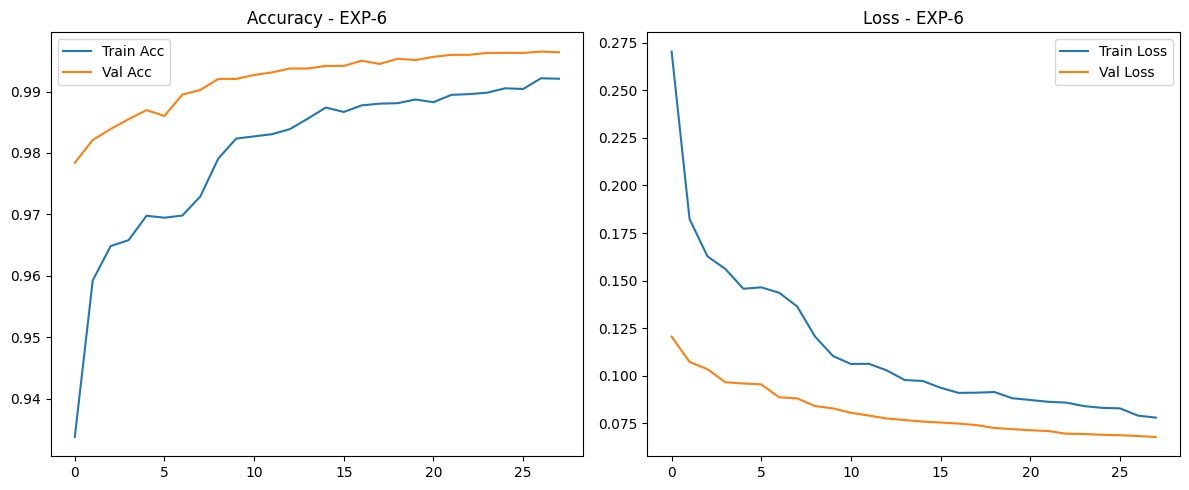

In [39]:
acc = history_pt6_stage1.history["accuracy"] + history_pt6_stage2.history["accuracy"]
val_acc = history_pt6_stage1.history["val_accuracy"] + history_pt6_stage2.history["val_accuracy"]
loss = history_pt6_stage1.history["loss"] + history_pt6_stage2.history["loss"]
val_loss = history_pt6_stage1.history["val_loss"] + history_pt6_stage2.history["val_loss"]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.title('Accuracy - EXP-6')
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Loss - EXP-6')
plt.legend()

plt.tight_layout()
plt.show()


In [40]:
model_pt6.save(os.path.join(save_dir, "animals10_exp6_pt6.h5"))

#### 7th experiment (edit the aggumentation + stronger head (Dense512) + stronger head (Dense512) + increase number of epochs)

In [41]:
img_size = (224, 224)
batch_size = 64

train_datagen_pt7 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.12,
    height_shift_range=0.12,
    zoom_range=0.20,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen_pt7 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds_pt7 = train_datagen_pt7.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds_pt7 = test_datagen_pt7.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

class_names = list(train_ds_pt7.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Num classes: 10


In [42]:
base_model_pt7 = EfficientNetB0(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3),
)
base_model_pt7.load_weights(EFFNET_WEIGHTS_PATH)

base_model_pt7.trainable = True

In [43]:
# unfreeze  last 60 layers
for layer in base_model_pt7.layers[:-60]:
    layer.trainable = False


for layer in base_model_pt7.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


In [44]:
model_pt7 = Sequential([
    base_model_pt7,
    GlobalAveragePooling2D(),
    Dense(512, activation="relu", kernel_regularizer=l2(2e-4)),
    Dropout(0.45),
    Dense(num_classes, activation="softmax")
])

model_pt7.summary()


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_5   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_8 (Dense)             (None, 512)               655872    
                                                                 
 dropout_4 (Dropout)         (None, 512)               0         
                                                                 
 dense_9 (Dense)             (None, 10)                5130      
                                                                 
Total params: 4,710,573
Trainable params: 3,310,282
Non-trainable params: 1,400,291
____________________________________

In [45]:
early_pt7 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_pt7 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

ckpt_pt7 = ModelCheckpoint(
    "animals_effnet_pt6_best.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


In [46]:
model_pt7.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [47]:
history_pt7 = model_pt7.fit(
    train_ds_pt7,
    epochs=25,
    validation_data=test_ds_pt7,
    steps_per_epoch=len(train_ds_pt7),
    validation_steps=len(test_ds_pt7),
    callbacks=[early_pt7, reduce_lr_pt7, ckpt_pt7],
)

Epoch 1/25
393/393 [==============================] - ETA: 0s - loss: 0.6792 - accuracy: 0.8497
Epoch 1: val_accuracy improved from -inf to 0.97396, saving model to animals_effnet_pt6_best.h5
393/393 [==============================] - 210s 519ms/step - loss: 0.6792 - accuracy: 0.8497 - val_loss: 0.2405 - val_accuracy: 0.9740 - lr: 3.0000e-05
Epoch 2/25
393/393 [==============================] - ETA: 0s - loss: 0.3065 - accuracy: 0.9509
Epoch 2: val_accuracy improved from 0.97396 to 0.97925, saving model to animals_effnet_pt6_best.h5
393/393 [==============================] - 196s 498ms/step - loss: 0.3065 - accuracy: 0.9509 - val_loss: 0.2157 - val_accuracy: 0.9793 - lr: 3.0000e-05
Epoch 3/25
393/393 [==============================] - ETA: 0s - loss: 0.2758 - accuracy: 0.9596
Epoch 3: val_accuracy improved from 0.97925 to 0.98190, saving model to animals_effnet_pt6_best.h5
393/393 [==============================] - 202s 514ms/step - loss: 0.2758 - accuracy: 0.9596 - val_loss: 0.2035 - 

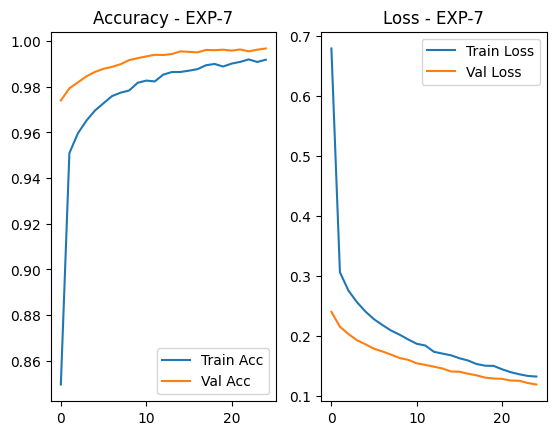

In [72]:
plt.subplot(1,2,1)
plt.plot(history_pt7.history['accuracy'], label='Train Acc')
plt.plot(history_pt7.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-7')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_pt7.history['loss'], label='Train Loss')
plt.plot(history_pt7.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-7')
plt.legend()


plt.show()

In [49]:
model_pt7.save(os.path.join(save_dir, "animals10_exp7_pt7.h5"))

#### 8th experiment (Augmentation INSIDE model + smaller head + RMSprop optimizer + unfreeze more layers)

In [50]:
img_size = (224, 224)
batch_size = 64

# NO heavy aug 
train_datagen_pt8 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen_pt8 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds_pt8 = train_datagen_pt8.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds_pt8 = test_datagen_pt8.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

class_names = list(train_ds_pt8.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Num classes: 10


In [51]:
base_model_pt8 = EfficientNetB0(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3),
)
base_model_pt8.load_weights(EFFNET_WEIGHTS_PATH)

base_model_pt8.trainable = True


In [52]:
# unfreeze only last 80 layers
for layer in base_model_pt8.layers[:-80]:
    layer.trainable = False

for layer in base_model_pt8.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


In [56]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast
from tensorflow.keras.optimizers import RMSprop
model_pt8 = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.08),
    RandomZoom(0.15),
    RandomContrast(0.10),

    base_model_pt8,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.30),
    Dense(num_classes, activation="softmax")
])


In [57]:
early_pt8 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_pt8 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

ckpt_pt8 = ModelCheckpoint(
    "animals_effnet_pt6_best.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


In [58]:
model_pt8.compile(
    optimizer=RMSprop(learning_rate=2e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [59]:
history_pt8 = model_pt8.fit(
    train_ds_pt8,
    epochs=25,
    validation_data=test_ds_pt8,
    steps_per_epoch=len(train_ds_pt8),
    validation_steps=len(test_ds_pt8),
    callbacks=[early_pt8, reduce_lr_pt8, ckpt_pt8],
)


Epoch 1/25
393/393 [==============================] - ETA: 0s - loss: 0.6972 - accuracy: 0.8151
Epoch 1: val_accuracy improved from -inf to 0.96623, saving model to animals_effnet_pt6_best.h5
393/393 [==============================] - 537s 1s/step - loss: 0.6972 - accuracy: 0.8151 - val_loss: 0.1572 - val_accuracy: 0.9662 - lr: 2.0000e-05
Epoch 2/25
393/393 [==============================] - ETA: 0s - loss: 0.2258 - accuracy: 0.9445
Epoch 2: val_accuracy improved from 0.96623 to 0.97565, saving model to animals_effnet_pt6_best.h5
393/393 [==============================] - 522s 1s/step - loss: 0.2258 - accuracy: 0.9445 - val_loss: 0.1249 - val_accuracy: 0.9757 - lr: 2.0000e-05
Epoch 3/25
393/393 [==============================] - ETA: 0s - loss: 0.1932 - accuracy: 0.9555
Epoch 3: val_accuracy improved from 0.97565 to 0.98031, saving model to animals_effnet_pt6_best.h5
393/393 [==============================] - 524s 1s/step - loss: 0.1932 - accuracy: 0.9555 - val_loss: 0.1087 - val_accur

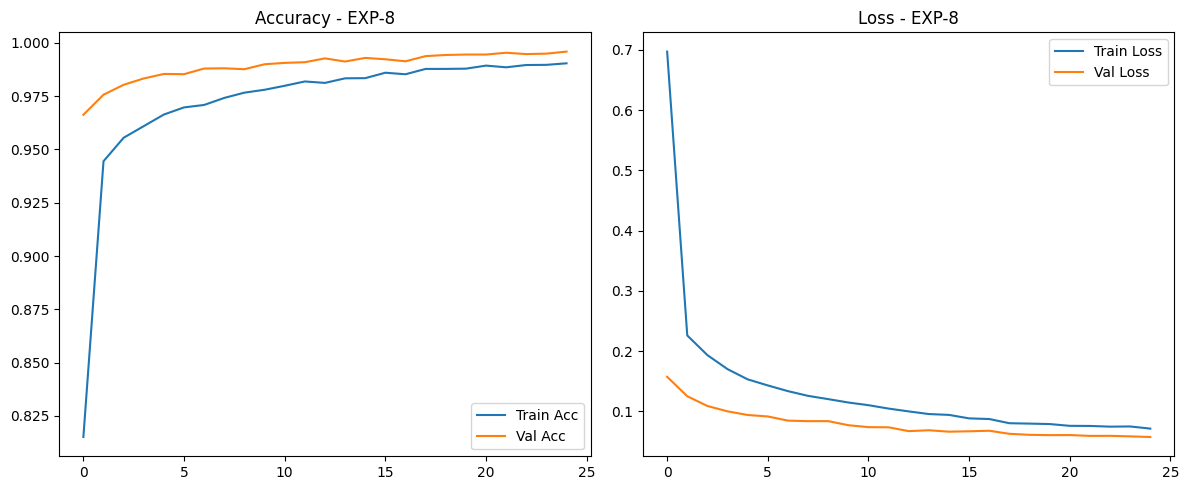

In [60]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_pt8.history['accuracy'], label='Train Acc')
plt.plot(history_pt8.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-8')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_pt8.history['loss'], label='Train Loss')
plt.plot(history_pt8.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-8')
plt.legend()

plt.tight_layout()
plt.show()

In [61]:
model_pt8.save(os.path.join(save_dir, "animals10_exp8_pt8.h5"))

#### 9th experiment (Fine-tune deeper (last 120 layers) + SGD momentum + smaller dropout + edit the head (dropout+lr + dense neurons) + increase number of epochs)

In [62]:
img_size = (224, 224)
batch_size = 64

# lighter aug for stability with SGD
train_datagen_pt9 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.12,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen_pt9 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds_pt9 = train_datagen_pt9.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds_pt9 = test_datagen_pt9.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

class_names = list(train_ds_pt9.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Num classes: 10


In [63]:
base_model_pt9 = EfficientNetB0(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3),
)
base_model_pt9.load_weights(EFFNET_WEIGHTS_PATH)

base_model_pt9.trainable = True


In [64]:
# unfreeze last 120 layers
for layer in base_model_pt9.layers[:-120]:
    layer.trainable = False

for layer in base_model_pt9.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


In [65]:
model_pt9 = Sequential([
    base_model_pt9,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu", kernel_regularizer=l2(8e-5)),
    Dropout(0.20),
    Dense(num_classes, activation="softmax")
])

model_pt9.summary()


Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_9   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_16 (Dense)            (None, 256)               327936    
                                                                 
 dropout_8 (Dropout)         (None, 256)               0         
                                                                 
 dense_17 (Dense)            (None, 10)                2570      
                                                                 
Total params: 4,380,077
Trainable params: 3,995,570
Non-trainable params: 384,507
______________________________________

In [66]:
early_pt9 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_pt9 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

ckpt_pt9 = ModelCheckpoint(
    "animals_effnet_pt6_best.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


In [68]:
from keras.optimizers import SGD
model_pt9.compile(
    optimizer=SGD(learning_rate=5e-5, momentum=0.9, nesterov=True),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [69]:
history_pt9 = model_pt9.fit(
    train_ds_pt9,
    epochs=30,
    validation_data=test_ds_pt9,
    steps_per_epoch=len(train_ds_pt9),
    validation_steps=len(test_ds_pt9),
    callbacks=[early_pt9, reduce_lr_pt9, ckpt_pt9],
)

Epoch 1/30
393/393 [==============================] - ETA: 0s - loss: 2.1432 - accuracy: 0.2945
Epoch 1: val_accuracy improved from -inf to 0.59998, saving model to animals_effnet_pt6_best.h5
393/393 [==============================] - 207s 509ms/step - loss: 2.1432 - accuracy: 0.2945 - val_loss: 1.7503 - val_accuracy: 0.6000 - lr: 5.0000e-05
Epoch 2/30
393/393 [==============================] - ETA: 0s - loss: 1.4436 - accuracy: 0.6509
Epoch 2: val_accuracy improved from 0.59998 to 0.81020, saving model to animals_effnet_pt6_best.h5
393/393 [==============================] - 197s 500ms/step - loss: 1.4436 - accuracy: 0.6509 - val_loss: 1.0671 - val_accuracy: 0.8102 - lr: 5.0000e-05
Epoch 3/30
393/393 [==============================] - ETA: 0s - loss: 0.8740 - accuracy: 0.8141
Epoch 3: val_accuracy improved from 0.81020 to 0.90230, saving model to animals_effnet_pt6_best.h5
393/393 [==============================] - 198s 503ms/step - loss: 0.8740 - accuracy: 0.8141 - val_loss: 0.5748 - 

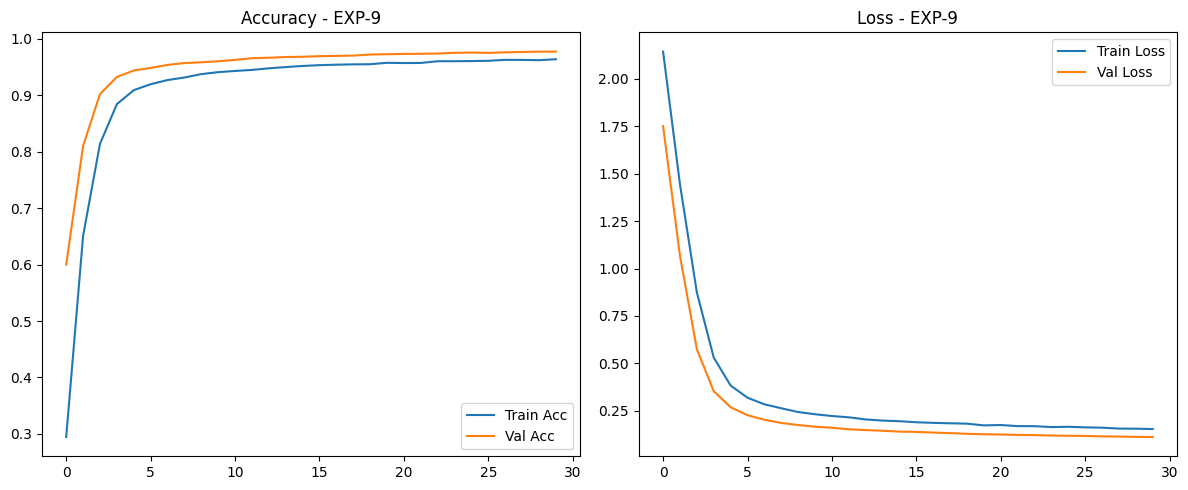

In [70]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_pt9.history['accuracy'], label='Train Acc')
plt.plot(history_pt9.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-9')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_pt9.history['loss'], label='Train Loss')
plt.plot(history_pt9.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-9')
plt.legend()

plt.tight_layout()
plt.show()

In [71]:
model_pt9.save(os.path.join(save_dir, "animals10_exp9_pt9.h5"))

#### 10th experiment (Switch labels to categorical + label smoothing  + Fine-tune a different range 80 layer + stronger head +  change the epoch number + edit dropout)

In [73]:

img_size = (224, 224)
batch_size = 64

train_datagen_pt10 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=(0.85, 1.15),
    fill_mode="nearest",
)

test_datagen_pt10 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds_pt10 = train_datagen_pt10.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",  
    shuffle=True,
    seed=42,
)

test_ds_pt10 = test_datagen_pt10.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",  
    shuffle=False,
)

class_names = list(train_ds_pt10.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Num classes: 10


In [74]:
base_model_pt10 = EfficientNetB0(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3),
)
base_model_pt10.load_weights(EFFNET_WEIGHTS_PATH)

base_model_pt10.trainable = True


In [77]:
for layer in base_model_pt10.layers[:-80]:
    layer.trainable = False

for layer in base_model_pt10.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


In [78]:
model_pt10 = Sequential([
    base_model_pt10,
    GlobalAveragePooling2D(),
    Dense(512, activation="relu", kernel_regularizer=l2(1e-4)),  
    Dropout(0.40),
    Dense(10, activation="softmax")
])
model_pt10.summary()


Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_11  (None, 1280)             0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_20 (Dense)            (None, 512)               655872    
                                                                 
 dropout_10 (Dropout)        (None, 512)               0         
                                                                 
 dense_21 (Dense)            (None, 10)                5130      
                                                                 
Total params: 4,710,573
Trainable params: 3,866,150
Non-trainable params: 844,423
_____________________________________

In [79]:
early_pt10 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_pt10 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

ckpt_pt10 = ModelCheckpoint(
    "animals_effnet_pt10_best.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [82]:
loss_pt10 = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.10)  

model_pt10.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=loss_pt10,
    metrics=["accuracy"]
)

In [84]:
history_pt10 = model_pt10.fit(
    train_ds_pt10,
    epochs=25,
    validation_data=test_ds_pt10,
    callbacks=[early_pt10, reduce_lr_pt10, ckpt_pt10]   
)

Epoch 1/25
393/393 [==============================] - ETA: 0s - loss: 0.7851 - accuracy: 0.9340
Epoch 1: val_accuracy improved from 0.95596 to 0.97004, saving model to animals_effnet_pt10_best.h5
393/393 [==============================] - 271s 689ms/step - loss: 0.7851 - accuracy: 0.9340 - val_loss: 0.6780 - val_accuracy: 0.9700 - lr: 1.0000e-05
Epoch 2/25
393/393 [==============================] - ETA: 0s - loss: 0.7371 - accuracy: 0.9498
Epoch 2: val_accuracy improved from 0.97004 to 0.97449, saving model to animals_effnet_pt10_best.h5
393/393 [==============================] - 246s 627ms/step - loss: 0.7371 - accuracy: 0.9498 - val_loss: 0.6588 - val_accuracy: 0.9745 - lr: 1.0000e-05
Epoch 3/25
393/393 [==============================] - ETA: 0s - loss: 0.7142 - accuracy: 0.9575
Epoch 3: val_accuracy improved from 0.97449 to 0.97830, saving model to animals_effnet_pt10_best.h5
393/393 [==============================] - 266s 676ms/step - loss: 0.7142 - accuracy: 0.9575 - val_loss: 0.6

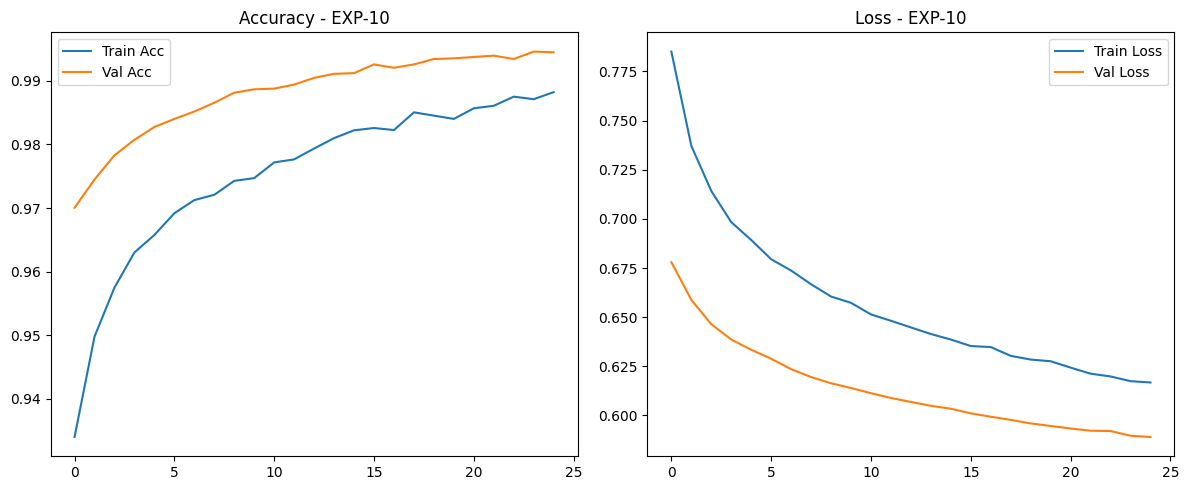

In [85]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_pt10.history['accuracy'], label='Train Acc')
plt.plot(history_pt10.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-10')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_pt10.history['loss'], label='Train Loss')
plt.plot(history_pt10.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-10')
plt.legend()

plt.tight_layout()
plt.show()

In [86]:
model_pt10.save(os.path.join(save_dir, "animals10_exp10_pt10.h5"))

### model selection 

#### we choose Model.pt6 in exp-6 because It reached the highest validation accuracy you got: val_accuracy = 0.99587 (≈ 99.587%) with a low val_loss ≈ 0.0572 and It also stayed stable late in training (no collapse / no big gap), so it’s a strong “final model” candidate for deployment.

##### Rebuild TEST generator (must be shuffle=False)

In [89]:
img_size = (224, 224)
batch_size = 64

test_datagen_eval = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_ds_eval = test_datagen_eval.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

class_names = list(test_ds_eval.class_indices.keys())
num_classes = len(class_names)

print("Classes:", class_names)
print("Num classes:", num_classes)
print("Test samples:", test_ds_eval.samples)


Found 9447 images belonging to 10 classes.
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Num classes: 10
Test samples: 9447


In [91]:
BEST_MODEL_PATH = "C:\\Users\\Waseem Al-mahainy\\Desktop\\UnI\\5th Year\\1st sem\\Jr\\Jr project\\Image classification what is this feature\\Image classification what is this feature Pretrained\\saved_models\\animals10_exp6_pt6.h5"
model_best = load_model(BEST_MODEL_PATH)

model_best.summary()
print(" Loaded:", BEST_MODEL_PATH)


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_4   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_6 (Dense)             (None, 256)               327936    
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                                 
 dense_7 (Dense)             (None, 10)                2570      
                                                                 
Total params: 4,380,077
Trainable params: 2,368,026
Non-trainable params: 2,012,051
____________________________________

#### Evaluation 

In [92]:
test_loss, test_acc = model_best.evaluate(
    test_ds_eval,
    steps=len(test_ds_eval),
    verbose=1
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)


148/148 [==============================] - 26s 168ms/step - loss: 0.0679 - accuracy: 0.9964
Test Accuracy: 0.9964009523391724
Test Loss: 0.06785564124584198


In [93]:
y_true = test_ds_eval.classes

y_prob = model_best.predict(
    test_ds_eval,
    steps=len(test_ds_eval),
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)

y_pred = y_pred[:len(y_true)]

cm = confusion_matrix(y_true, y_pred)

print(" Confusion Matrix shape:", cm.shape)


148/148 [==============================] - 26s 166ms/step
 Confusion Matrix shape: (10, 10)


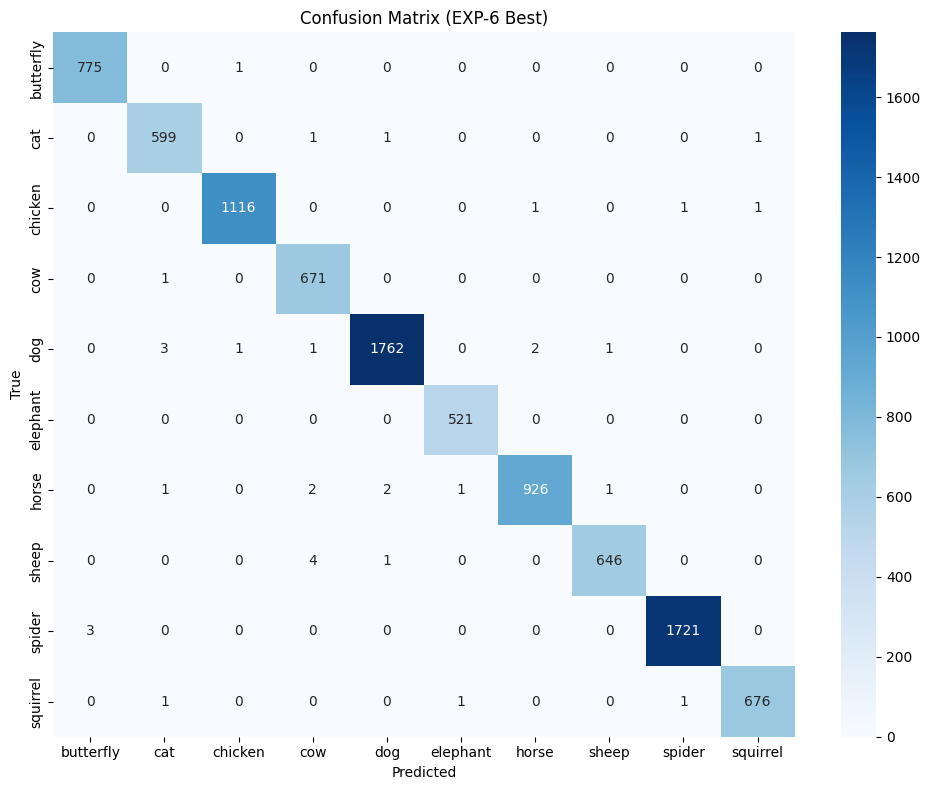

In [94]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix (EXP-6 Best)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [95]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

for i, name in enumerate(class_names):
    print(f"{name:15s}  acc = {per_class_acc[i]*100:.2f}%")

print("Mean per-class accuracy:", np.mean(per_class_acc)*100)


butterfly        acc = 99.87%
cat              acc = 99.50%
chicken          acc = 99.73%
cow              acc = 99.85%
dog              acc = 99.55%
elephant         acc = 100.00%
horse            acc = 99.25%
sheep            acc = 99.23%
spider           acc = 99.83%
squirrel         acc = 99.56%
Mean per-class accuracy: 99.63697544663799


In [96]:
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4
)

print(report)


              precision    recall  f1-score   support

   butterfly     0.9961    0.9987    0.9974       776
         cat     0.9901    0.9950    0.9925       602
     chicken     0.9982    0.9973    0.9978      1119
         cow     0.9882    0.9985    0.9933       672
         dog     0.9977    0.9955    0.9966      1770
    elephant     0.9962    1.0000    0.9981       521
       horse     0.9968    0.9925    0.9946       933
       sheep     0.9969    0.9923    0.9946       651
      spider     0.9988    0.9983    0.9985      1724
    squirrel     0.9971    0.9956    0.9963       679

    accuracy                         0.9964      9447
   macro avg     0.9956    0.9964    0.9960      9447
weighted avg     0.9964    0.9964    0.9964      9447



### saving the final model 

In [116]:

FINAL_MODEL_PATH = r"C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\Image classification what is this feature Pretrained\saved_models\Final\animals10_effnet_EXP6_FINAL.h5"
LABELS_PATH = r"C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\Image classification what is this feature Pretrained\saved_models\Final\animals10_class_names.json"

model_best.save(FINAL_MODEL_PATH)

class_indices = train_ds_pt6.class_indices  
class_names_list = [None] * len(class_indices)
for name, idx in class_indices.items():
    class_names_list[idx] = name

with open(LABELS_PATH, "w") as f:
    json.dump(class_names_list, f, indent=2)

print(" Saved model to:", FINAL_MODEL_PATH)
print(" Saved class names to:", LABELS_PATH)
print(" Class names list:", class_names_list)


 Saved model to: C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\Image classification what is this feature Pretrained\saved_models\Final\animals10_effnet_EXP6_FINAL.h5
 Saved class names to: C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\Image classification what is this feature Pretrained\saved_models\Final\animals10_class_names.json
 Class names list: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


#### Verification and test (Load model + labels (after saving))

In [117]:
import json
from tensorflow.keras.models import load_model

MODEL_PATH = r"C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\Image classification what is this feature Pretrained\saved_models\Final\animals10_effnet_EXP6_FINAL.h5"
LABELS_PATH = r"C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\Image classification what is this feature Pretrained\saved_models\Final\animals10_class_names.json"

model_loaded = load_model(MODEL_PATH, compile=False)

with open(LABELS_PATH, "r") as f:
    class_names = json.load(f)  

print("Done model loaded")
print("Done labels loaded")
print("Classes:", class_names)


Done model loaded
Done labels loaded
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


#### testing the model 

In [119]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_image(image_path, img_size=(224, 224), top_k=3):
    img = load_img(image_path, target_size=img_size)
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    probs = model_loaded.predict(x, verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:top_k]

    results = []
    for i in top_idx:
        results.append((class_names[i], float(probs[i])))

    return results


print(predict_image(r"C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\Image classification what is this feature Pretrained\test\dog2.jpeg"))


[('dog', 1.0), ('sheep', 4.76837158203125e-07), ('cat', 1.1920928955078125e-07)]
